In [1]:
#include <dlfcn.h>
#include <iostream>

dlopen("CudaSourse/libcuda.so", RTLD_NOW | RTLD_GLOBAL);

In [2]:
extern "C" void run_add(int a, int b, int *result);

In [3]:
int result = 0;
run_add(2, 3, &result);
std::cout << result << std::endl;

5


In [4]:
#include <iostream>
#include <cuda_runtime.h>

dlopen("CudaSourse/libcuda.so", RTLD_NOW | RTLD_GLOBAL);

In [5]:
extern "C" void run_vector_add(int N, int *a, int *b, int *c);

In [6]:
const int N = 10;
int a[N], b[N], c[N];

for (int i = 0; i < N; i++) {
    a[i] = i;
    b[i] = i * i;
}

run_vector_add(N, a, b, c);

for (int i = 0; i < N; i++) {
    std::cout << a[i] << " + " << b[i] << " = " << c[i] << "\n";
}

0 + 0 = 0
1 + 1 = 2
2 + 4 = 6
3 + 9 = 12
4 + 16 = 20
5 + 25 = 30
6 + 36 = 42
7 + 49 = 56
8 + 64 = 72
9 + 81 = 90


In [7]:
extern "C" void run_julia(unsigned char *output);

In [8]:
#define STB_IMAGE_WRITE_IMPLEMENTATION
#include "stb_image_write.h"

const int DIM = 1000;

unsigned char *bitmap = new unsigned char[DIM * DIM * 4];
run_julia(bitmap);
stbi_write_png("julia.png", DIM, DIM, 4, bitmap, DIM * 4);
std::cout << "Saved to julia.png" << std::endl;
delete[] bitmap;

Saved to julia.png


In [9]:
#include <string>
#include <fstream>
#include <sstream>
#include "nlohmann/json.hpp"
#include "xeus/xbase64.hpp"

namespace nl = nlohmann;

namespace im
{
    struct image
    {
        inline image(const std::string& filename)
        {
            std::ifstream fin(filename, std::ios::binary);
            m_buffer << fin.rdbuf();
        }

        std::stringstream m_buffer;
    };

    nl::json mime_bundle_repr(const image& i)
    {
        auto bundle = nl::json::object();
        bundle["image/png"] = xeus::base64encode(i.m_buffer.str());
        return bundle;
    }
}

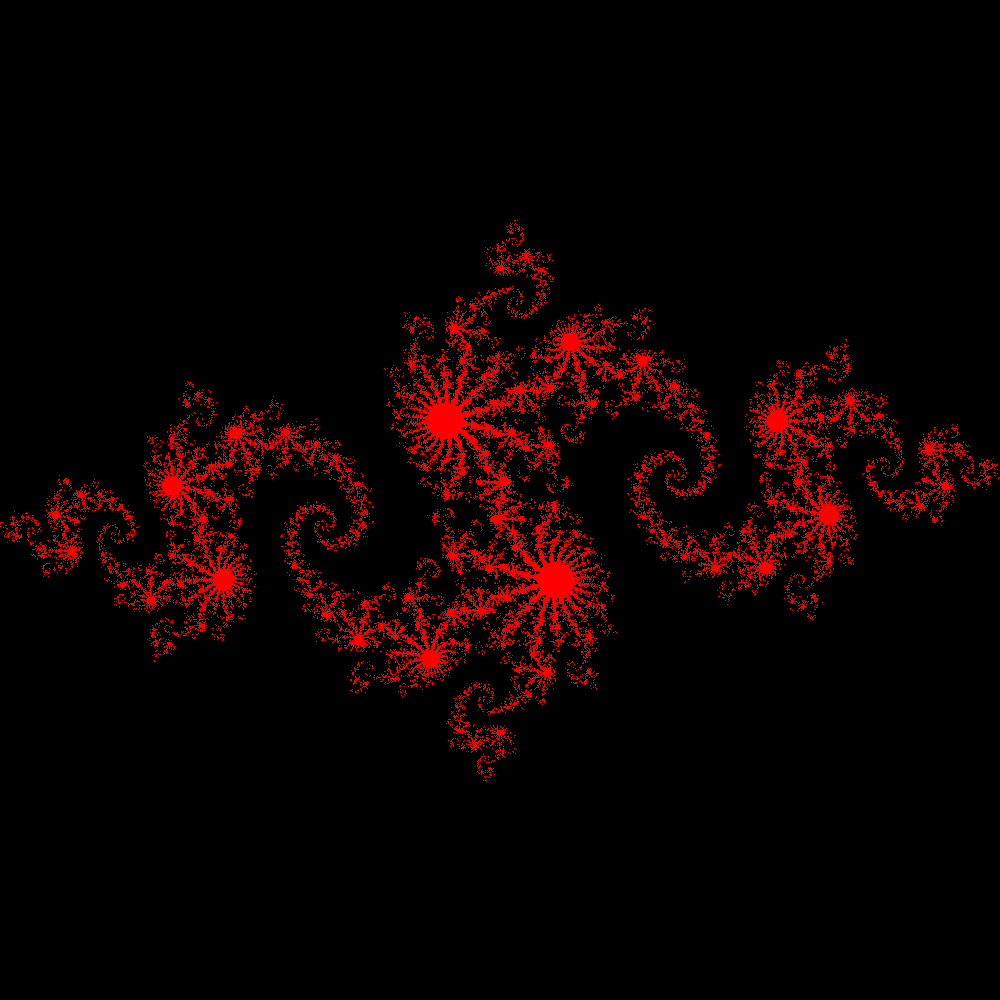

In [10]:
#include "xcpp/xdisplay.hpp"

im::image julia("julia.png");
xcpp::display(julia);